In [ ]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.
#
# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
#

import math
from logging import getLogger
from multiprocessing import Value

import torch

_GLOBAL_SEED = 0
logger = getLogger()


class MaskCollator(object):
    def __init__(
        self,
        input_size=(224, 224),
        patch_size=16,
        enc_mask_scale=(0.2, 0.8),
        pred_mask_scale=(0.2, 0.8),
        aspect_ratio=(0.3, 3.0),
        nenc=1,
        npred=2,
        min_keep=4,
        allow_overlap=False,
    ):
        super(MaskCollator, self).__init__()
        if not isinstance(input_size, tuple):
            input_size = (input_size,) * 2
        self.patch_size = patch_size
        self.height, self.width = (
            input_size[0] // patch_size,
            input_size[1] // patch_size,
        )
        self.enc_mask_scale = enc_mask_scale
        self.pred_mask_scale = pred_mask_scale
        self.aspect_ratio = aspect_ratio
        self.nenc = nenc
        self.npred = npred
        self.min_keep = min_keep  # minimum number of patches to keep
        self.allow_overlap = (
            allow_overlap  # whether to allow overlap b/w enc and pred masks
        )
        self._itr_counter = Value("i", -1)  # collator is shared across worker processes

    def step(self):
        i = self._itr_counter
        with i.get_lock():
            i.value += 1
            v = i.value
        return v

    def _sample_block_size(self, generator, scale, aspect_ratio_scale):
        _rand = torch.rand(1, generator=generator).item()
        # -- Sample block scale
        min_s, max_s = scale
        mask_scale = min_s + _rand * (max_s - min_s)
        max_keep = int(self.height * self.width * mask_scale)
        # -- Sample block aspect-ratio
        min_ar, max_ar = aspect_ratio_scale
        aspect_ratio = min_ar + _rand * (max_ar - min_ar)
        # -- Compute block height and width (given scale and aspect-ratio)
        h = int(round(math.sqrt(max_keep * aspect_ratio)))
        w = int(round(math.sqrt(max_keep / aspect_ratio)))
        while h >= self.height:
            h -= 1
        while w >= self.width:
            w -= 1

        return (h, w)

    def _sample_block_mask(self, b_size, acceptable_regions=None):
        h, w = b_size

        def constrain_mask(mask, tries=0):
            """Helper to restrict given mask to a set of acceptable regions"""
            N = max(int(len(acceptable_regions) - tries), 0)
            for k in range(N):
                mask *= acceptable_regions[k]

        # --
        # -- Loop to sample masks until we find a valid one
        tries = 0
        timeout = og_timeout = 20
        valid_mask = False
        while not valid_mask:
            # -- Sample block top-left corner
            top = torch.randint(0, self.height - h, (1,))
            left = torch.randint(0, self.width - w, (1,))
            mask = torch.zeros((self.height, self.width), dtype=torch.int32)
            mask[top : top + h, left : left + w] = 1
            # -- Constrain mask to a set of acceptable regions
            if acceptable_regions is not None:
                constrain_mask(mask, tries)
            mask = torch.nonzero(mask.flatten())
            # -- If mask too small try again
            valid_mask = len(mask) > self.min_keep
            if not valid_mask:
                timeout -= 1
                if timeout == 0:
                    tries += 1
                    timeout = og_timeout
                    logger.warning(
                        f'Mask generator says: "Valid mask not found, decreasing acceptable-regions [{tries}]"'
                    )
        mask = mask.squeeze()
        # --
        mask_complement = torch.ones((self.height, self.width), dtype=torch.int32)
        mask_complement[top : top + h, left : left + w] = 0
        # --
        return mask, mask_complement

    def __call__(self, batch):
        """
        Create encoder and predictor masks when collating imgs into a batch
        # 1. sample enc block (size + location) using seed
        # 2. sample pred block (size) using seed
        # 3. sample several enc block locations for each image (w/o seed)
        # 4. sample several pred block locations for each image (w/o seed)
        # 5. return enc mask and pred mask
        """
        B = len(batch)

        collated_batch = torch.utils.data.default_collate(batch)

        seed = self.step()
        g = torch.Generator()
        g.manual_seed(seed)
        p_size = self._sample_block_size(
            generator=g,
            scale=self.pred_mask_scale,
            aspect_ratio_scale=self.aspect_ratio,
        )
        e_size = self._sample_block_size(
            generator=g, scale=self.enc_mask_scale, aspect_ratio_scale=(1.0, 1.0)
        )

        collated_masks_pred, collated_masks_enc = [], []
        min_keep_pred = self.height * self.width
        min_keep_enc = self.height * self.width
        for _ in range(B):
            masks_p, masks_C = [], []
            for _ in range(self.npred):
                mask, mask_C = self._sample_block_mask(p_size)
                masks_p.append(mask)
                masks_C.append(mask_C)
                min_keep_pred = min(min_keep_pred, len(mask))
            collated_masks_pred.append(masks_p)

            acceptable_regions = masks_C
            try:
                if self.allow_overlap:
                    acceptable_regions = None
            except Exception as e:
                logger.warning(f"Encountered exception in mask-generator {e}")

            masks_e = []
            for _ in range(self.nenc):
                mask, _ = self._sample_block_mask(
                    e_size, acceptable_regions=acceptable_regions
                )
                masks_e.append(mask)
                min_keep_enc = min(min_keep_enc, len(mask))
            collated_masks_enc.append(masks_e)

        collated_masks_pred = [
            [cm[:min_keep_pred] for cm in cm_list] for cm_list in collated_masks_pred
        ]
        collated_masks_pred = torch.utils.data.default_collate(collated_masks_pred)
        # --
        collated_masks_enc = [
            [cm[:min_keep_enc] for cm in cm_list] for cm_list in collated_masks_enc
        ]
        collated_masks_enc = torch.utils.data.default_collate(collated_masks_enc)

        return collated_batch, collated_masks_enc, collated_masks_pred

In [83]:
mc = MaskCollator(
    nenc=1, npred=2, enc_mask_scale=(0.5, 0.8), pred_mask_scale=(0.2, 0.6), min_keep=10
)

bs = 2
batch = [torch.randn(3, 224, 224) for _ in range(bs)]
batch, masks_c, masks_pred = mc(batch)
print(batch.shape)
print(masks_c[0].shape, len(masks_c))  # [bs, ctx_len], n_enc_mask
print(masks_pred[0].shape, len(masks_pred))  # [bs, pred_len], n_pred_mask

torch.Size([2, 3, 224, 224])
torch.Size([2, 47]) 1
torch.Size([2, 77]) 2


torch.Size([2, 196, 3])
torch.Size([14, 14, 3])
torch.Size([2, 47, 3])


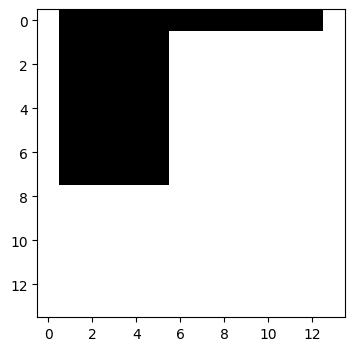

In [84]:
import matplotlib.pyplot as plt
from einops import repeat
from einx import get_at, rearrange, set_at

# masks_pred[0].shape
ph, pw = int(224 / 16), int(224 / 16)
ones = torch.ones(ph, pw)
ones = ones[None, None].repeat(bs, 3, 1, 1)
ones = rearrange("bs c h w -> bs (h w) c", ones)
print(ones.shape)

# mask encoder
mask_c = masks_c[0]  # [bs, ctx_len]
# scatter to zero which is masked
update_ = torch.zeros(bs, mask_c.shape[1], 3)
ones_mask_c = set_at("bs [seq_img] c, bs masked, bs masked c", ones, mask_c, update_)

# show the first batch item
ones_mask_c0 = rearrange("bs (h w) c -> bs h w c", ones_mask_c, h=ph, w=pw)[0].float()
print(ones_mask_c0.shape)
plt.figure(figsize=(4, 4))
plt.imshow(ones_mask_c0)

# get at
encoder_seen_tokens = get_at("bs [s] c, bs masked -> bs masked c", ones, mask_c)
print(encoder_seen_tokens.shape)
assert encoder_seen_tokens.shape[1] == mask_c.shape[1]

torch.Size([2, 77])
torch.Size([14, 14, 3])


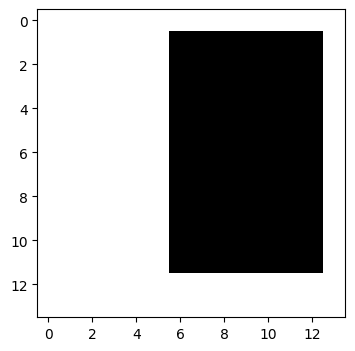

In [85]:
ph, pw = int(224 / 16), int(224 / 16)
ones = torch.ones(ph, pw)
ones = ones[None, None].repeat(bs, 3, 1, 1)
ones = rearrange("bs c h w -> bs (h w) c", ones)

mask_p0 = masks_pred[1]  # [bs, ctx_len]
# mask_p1 = masks_pred[1]
print(mask_p0.shape)

update_ = torch.zeros(bs, mask_p0.shape[1], 3)
ones_mask_p0 = set_at(
    "bs [seq_img] c, bs masked, bs masked c", ones.clone(), mask_p0, update_
)

# update_ = torch.zeros(bs, mask_p1.shape[1], 3)
# _copy_masked_p0 = ones_mask_p0.clone()
# ones_mask_p1 = set_at(
#     "bs [seq_img] c, bs masked, bs masked c", _copy_masked_p0, mask_p1, update_
# )

ones_mask_p0 = rearrange("bs (h w) c -> bs h w c", ones_mask_p0, h=ph, w=pw)[0].float()
print(ones_mask_p0.shape)
plt.figure(figsize=(4, 4))
plt.imshow(ones_mask_p0)

# show the first batch item
# ones_mask_p1 = rearrange("bs (h w) c -> bs h w c", ones_mask_p1, h=ph, w=pw)[0].float()
# print(ones_mask_p1.shape)
# plt.figure(figsize=(4, 4))
# plt.imshow(ones_mask_p1)